In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style="darkgrid", font="serif") #TODO: fix with actual thesis font


def get_mb(matrix_name, symmetric):
    if symmetric:
        matrix_name = "symmetric/" + matrix_name
    else:
        matrix_name = "unsymmetric/" + matrix_name

    f_path = os.path.join(matrix_path, matrix_name)
    try:
        return round(os.path.getsize(f_path) / (1024**2))
    except: return None

matrix_path = "/home/mengelsl/MA-bench-framework/matrices/binary_spmc"
results_path = "/home/mengelsl/MA-bench-framework/outputs/krylov"

main_folder = {
    "Native": results_path + "/native/",
    "SME": results_path + "/sme/",
    "SME+SEV": results_path + "/sev/",
    "Native_interleave": results_path + "/native_interleave/",
    "SME_interleave": results_path + "/sme_interleave/",
    "SME+SEV_interleave": results_path + "/sev_interleave/",
}

In [2]:
results_list = []

for label, path in main_folder.items():
    f_path = os.path.join(path, "results.csv")
    print(f"Checking for {label} at {f_path}...")
    if os.path.exists(f_path):
        df = pd.read_csv(f_path)
        print(f"Loaded {len(df)} rows for {label}.")
        df["Mode"] = label.split("_interleave")[0]
        df["VM_NUMA"] = "interleave" if "interleave" in label else "strict"
        results_list.append(df)

df_raw = pd.concat(results_list, ignore_index=True)
df_raw.rename(columns={"Process_NUMA_Policy": "Process_NUMA"}, inplace=True)

Checking for Native at /home/mengelsl/MA-bench-framework/outputs/krylov/native/results.csv...
Loaded 2400 rows for Native.
Checking for SME at /home/mengelsl/MA-bench-framework/outputs/krylov/sme/results.csv...
Loaded 2400 rows for SME.
Checking for SME+SEV at /home/mengelsl/MA-bench-framework/outputs/krylov/sev/results.csv...
Loaded 2400 rows for SME+SEV.
Checking for Native_interleave at /home/mengelsl/MA-bench-framework/outputs/krylov/native_interleave/results.csv...
Loaded 2400 rows for Native_interleave.
Checking for SME_interleave at /home/mengelsl/MA-bench-framework/outputs/krylov/sme_interleave/results.csv...
Loaded 2400 rows for SME_interleave.
Checking for SME+SEV_interleave at /home/mengelsl/MA-bench-framework/outputs/krylov/sev_interleave/results.csv...
Loaded 2400 rows for SME+SEV_interleave.


In [3]:
config_cols_raw = ["Mode", "Matrix", "Cores", "Process_NUMA", "VM_NUMA", "Algo", "Arg1", "Arg2", "Arg3", "N_Ops"]
metric_cols_raw = [ "SpMV_Time", "Mgmt_Time", "Perf_Cycles", "Perf_Instructions", "Perf_CacheMisses", "Perf_dTLBMisses" ]

config_drop_counts = []

def iqr_filter(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for c in cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        mask &= df[c].between(lower, upper)
    return df[mask]

def iqr_mark_outliers(group):
    group = group.copy()
    group_drops = 0

    for col in metric_cols_raw:
        if col not in group.columns:
            continue

        valid_rows = group[[col]].dropna()
        if valid_rows.empty:
            continue

        filtered_rows = iqr_filter(valid_rows, [col])
        outlier_idx = valid_rows.index.difference(filtered_rows.index)

        group_drops += len(outlier_idx)
        group.loc[outlier_idx, col] = np.nan

    config_drop_counts.append(group_drops)
    return group

df_clean = df_raw.groupby(config_cols_raw).apply(iqr_mark_outliers, include_groups=False).reset_index()

total_points_removed = np.sum(config_drop_counts)

print(f"Total metric data points: {len(df_raw) * len(metric_cols_raw)}")
print(f"Total data points removed: {total_points_removed}")
print(f"Data points removed (%): {total_points_removed / (len(df_raw) * len(metric_cols_raw)) * 100:.2f}%")



Total metric data points: 86400
Total data points removed: 2608
Data points removed (%): 3.02%


In [4]:
def compute_cv(df, config_cols_raw, metrics):
    stats = (
        df
        .groupby(config_cols_raw)[metrics]
        .agg(["mean", "std"])
    )
    
    cv = stats.xs("std", level=1, axis=1) / stats.xs("mean", level=1, axis=1)

    return cv.mean()

cv_raw = compute_cv(df_raw, config_cols_raw, metric_cols_raw)
cv_clean = compute_cv(df_clean, config_cols_raw, metric_cols_raw)

# Print the values displayed in the heatmaps
print("CV (Raw Data):")
print(cv_raw.round(3).to_string())
print("\nCV (IQR Cleaned Data):")
print(cv_clean.round(3).to_string())

CV (Raw Data):
SpMV_Time            0.003
Mgmt_Time            0.004
Perf_Cycles          0.002
Perf_Instructions    0.000
Perf_CacheMisses     0.010
Perf_dTLBMisses      0.067

CV (IQR Cleaned Data):
SpMV_Time            0.003
Mgmt_Time            0.003
Perf_Cycles          0.002
Perf_Instructions    0.000
Perf_CacheMisses     0.009
Perf_dTLBMisses      0.060


In [5]:
df = df_clean.groupby(config_cols_raw)[metric_cols_raw].median().reset_index()

#Explicit filter, as funnily "bicgstab" contains "cg" but is not symmetric.
df["Symmetric"] = df["Algo"].apply(lambda x: ("cg" in x or "lanczos" in x) and "bicg" not in x)
df['MB'] = df.apply(lambda row: get_mb(row['Matrix'], row['Symmetric']), axis=1).astype('Int64')
df["Matrix"] = df["Matrix"].apply(lambda x: x.split(".bin")[0]) 
df["Perf_IPC"] = df['Perf_Instructions'] / df['Perf_Cycles']
df["Total_Time"] = df["SpMV_Time"] + df["Mgmt_Time"]
df["Time_per_op"] = df["Total_Time"] / df["N_Ops"]
df["SpMV_Ratio"] = df["SpMV_Time"] / (df["SpMV_Time"] + df["Mgmt_Time"]) 

metric_cols = metric_cols_raw + ["Perf_IPC", "Time_per_op"]

df.head()

,Mode,Matrix,Cores,Process_NUMA,VM_NUMA,Algo,Arg1,Arg2,Arg3,N_Ops,...,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Symmetric,MB,Perf_IPC,Total_Time,Time_per_op,SpMV_Ratio
0,Native,Bump2911,1,interleave,interleave,cg,159,0,0,159,...,3.561613e+10,1.536218e+11,58302643.0,533281.0,True,1473,4.313265,9.801176,0.061643,0.864033
1,Native,Bump2911,1,interleave,interleave,lanczos,11,2,10,106,...,3.147399e+10,1.198801e+11,37869017.0,257503.0,True,1473,3.808863,8.781362,0.082843,0.647692
2,Native,Bump2911,1,interleave,strict,cg,159,0,0,159,...,3.701111e+10,1.536218e+11,58115339.0,516729.0,True,1473,4.150694,10.187805,0.064074,0.863784
3,Native,Bump2911,1,interleave,strict,lanczos,11,2,10,106,...,3.208136e+10,1.198801e+11,37515727.0,247792.0,True,1473,3.736755,8.941120,0.084350,0.657623
4,Native,Bump2911,1,membind,interleave,cg,159,0,0,159,...,3.557956e+10,1.536218e+11,58030389.0,504352.5,True,1473,4.317698,9.790518,0.061576,0.863985


Time per Operation (seconds):
Mode     VM_NUMA   
Native   interleave    0.026670
         strict        0.028410
SME      interleave    0.027366
         strict        0.029777
SME+SEV  interleave    0.027418
         strict        0.030023


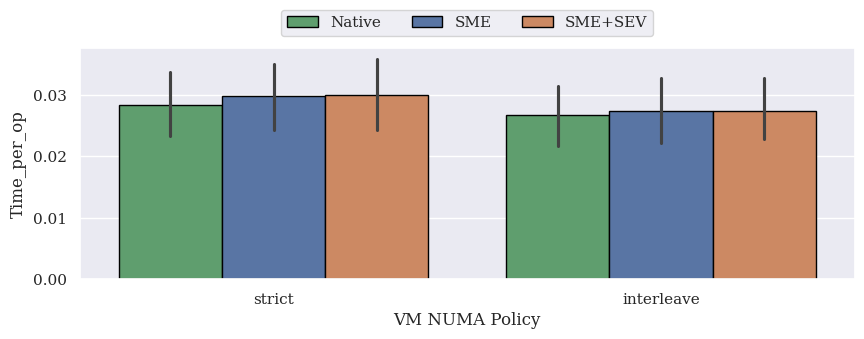

In [6]:
base = sns.color_palette("deep", 3)
palette = {
    "Native": base[2],  
    "SME": base[0],     
    "SME+SEV": base[1] 
}
plt.figure(figsize=(10, 3))
sns.barplot(data=df, x="VM_NUMA", y="Time_per_op", hue="Mode", edgecolor="black", order=["strict", "interleave"], palette=palette)
plt.xlabel("VM NUMA Policy")
plt.legend(title=None, loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)
plt.savefig("images/krylov_vm_numa.pdf", bbox_inches="tight")
print("Time per Operation (seconds):")
print(df.groupby(["Mode", "VM_NUMA"])["Time_per_op"].mean().round(6).to_string())

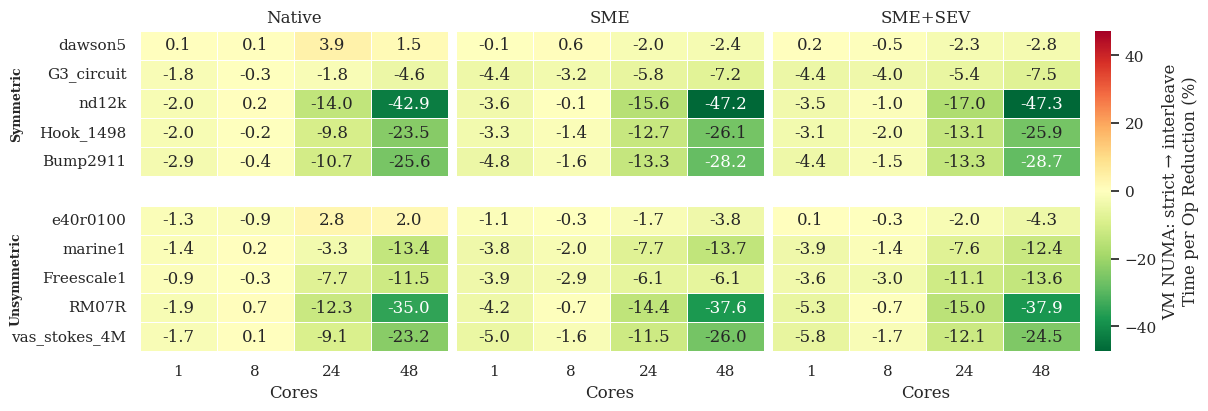

In [7]:
# VM_NUMA boost: interleave vs strict
heat_df = (
	df.pivot_table(
		index=["Mode", "Algo", "Matrix", "Cores", "Process_NUMA"],
		columns="VM_NUMA",
		values="Time_per_op",
		aggfunc="mean"
	)
	.dropna(subset=["interleave", "strict"])
	.reset_index()
)

heat_df["Boost_pct"] = (heat_df["interleave"] - heat_df["strict"]) / heat_df["strict"] * 100

mode_cell = (
	heat_df.groupby(["Matrix", "Cores", "Mode"], as_index=False)["Boost_pct"]
	.mean()
)

mode_order = ["Native", "SME", "SME+SEV"]
modes = [m for m in mode_order if m in mode_cell["Mode"].unique()]

vabs = mode_cell["Boost_pct"].abs().max()
fig, axes = plt.subplots(1, len(modes), figsize=(12, 4), constrained_layout=True, sharey=True)
fig.patch.set_facecolor("white")

if len(modes) == 1:
	axes = [axes]

for i, mode in enumerate(modes):
	axes[i].set_facecolor("white")

	p_mode = (
		mode_cell[mode_cell["Mode"] == mode]
		.pivot(index="Matrix", columns="Cores", values="Boost_pct")
	)
	p_mode = p_mode.reindex(sorted(p_mode.columns), axis=1)

	mb_map = df[["Matrix", "MB"]].drop_duplicates().set_index("Matrix")["MB"]
	sym_map = df[["Matrix", "Symmetric"]].drop_duplicates().set_index("Matrix")["Symmetric"]

	available_rows = list(p_mode.index)
	sym_rows = [m for m in available_rows if bool(sym_map.get(m, False))]
	unsym_rows = [m for m in available_rows if not bool(sym_map.get(m, False))]

	sym_sorted = sorted(sym_rows, key=lambda m: int(mb_map.get(m, 0)))
	unsym_sorted = sorted(unsym_rows, key=lambda m: int(mb_map.get(m, 0)))

	combined_index = sym_sorted + [""] + unsym_sorted
	p_combined = p_mode.reindex(combined_index)
	mask = p_combined.isna()

	sns.heatmap(
		p_combined,
		ax=axes[i],
		cmap="RdYlGn_r",
		center=0,
		vmin=-vabs,
		vmax=vabs,
		annot=True,
		fmt=".1f",
		linewidths=0.4,
		linecolor="white",
		mask=mask,
		cbar=(i == len(modes) - 1),
		cbar_kws={"label": "VM NUMA: strict → interleave\nTime per Op Reduction (%)"} if i == len(modes) - 1 else None
	)

	if i == 0:
		sym_count = len(sym_sorted)
		unsym_count = len(unsym_sorted)

		if sym_count > 0:
			sym_y = sym_count / 2.0
			axes[i].text(-1.6, sym_y, "Symmetric", va="center", ha="center",
						 rotation=90, fontsize=9, fontweight="bold", clip_on=False)
		if unsym_count > 0:
			unsym_y = sym_count + 1 + (unsym_count / 2.0)
			axes[i].text(-1.6, unsym_y, "Unsymmetric", va="center", ha="center",
						 rotation=90, fontsize=9, fontweight="bold", clip_on=False)

	axes[i].set_yticks(np.arange(len(p_combined.index)) + 0.5)
	axes[i].set_yticklabels(p_combined.index, rotation=0)

	axes[i].set_title(mode)
	axes[i].set_xlabel("Cores")
	if i == 0:
		axes[i].set_ylabel("")
	else:
		axes[i].set_ylabel("")
		axes[i].tick_params(axis="y", left=False, labelleft=False)

plt.savefig("images/krylov_vm_numa_heat.pdf", bbox_inches="tight")


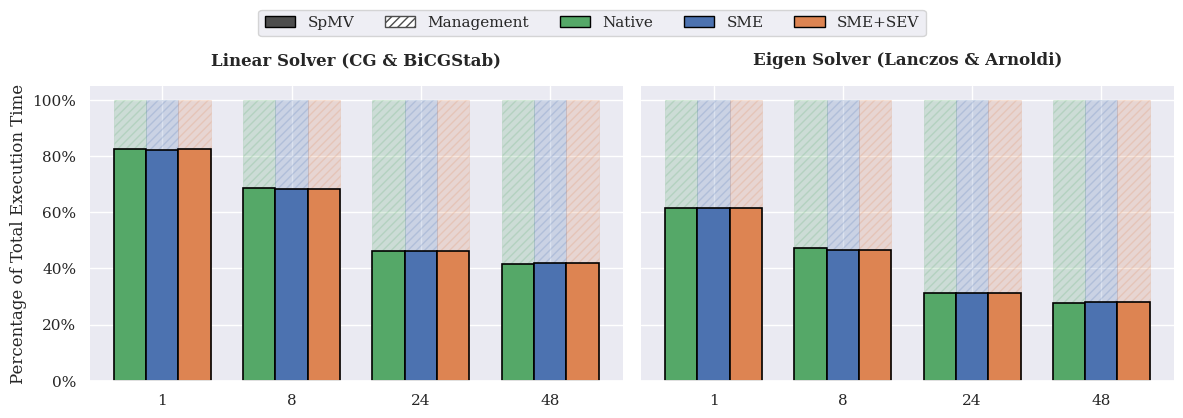


Linear Solver (CG & BiCGStab) SpMV Ratio (% of total time):
Mode   Native    SME  SME+SEV
Cores                        
1      82.37% 82.33%   82.37%
8      68.60% 68.23%   68.22%
24     46.29% 46.05%   46.04%
48     41.59% 41.89%   41.78%

Eigen Solver (Lanczos & Arnoldi) SpMV Ratio (% of total time):
Mode   Native    SME  SME+SEV
Cores                        
1      61.59% 61.58%   61.60%
8      47.12% 46.66%   46.62%
24     31.35% 31.16%   31.12%
48     27.86% 28.05%   28.04%


In [8]:
# 1. Prep Data
plot_df = df.groupby(['Mode', 'Cores'])['SpMV_Ratio'].mean().unstack(0)
target_order = [m for m in ['Native', 'SME', 'SME+SEV'] if m in df['Mode'].unique()]
cores = sorted(df['Cores'].unique())
x = np.arange(len(cores))
width = 0.25

# 2. Color Mapping (Native=2, SME=0, SME+SEV=1)
std_palette = sns.color_palette("deep")
color_map = {
    'Native': std_palette[2],
    'SME': std_palette[0],
    'SME+SEV': std_palette[1]
}

# 3. Define algo groups for subplots
algo_groups = [
    {'name': 'Linear Solver (CG & BiCGStab)', 'algos': ['cg', 'bicgstab'], 'ax_idx': 0},
    {'name': 'Eigen Solver (Lanczos & Arnoldi)', 'algos': ['lanczos', 'arnoldi'], 'ax_idx': 1}
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for group in algo_groups:
    ax = axes[group['ax_idx']]
    
    # Filter data for this specific algo group
    filtered_df = df[df['Algo'].isin(group['algos'])]
    plot_df_filtered = filtered_df.groupby(['Mode', 'Cores'])['SpMV_Ratio'].mean().unstack(0)
    
    # Ensure columns match our target order and exist in data
    current_modes = [m for m in target_order if m in plot_df_filtered.columns]
    plot_df_filtered = plot_df_filtered[current_modes]
    
    # Plotting loop
    for i, mode in enumerate(plot_df_filtered.columns):
        # Calculate horizontal offset for grouped bars
        pos = x + (i - (len(plot_df_filtered.columns)-1)/2) * width
        ratios = plot_df_filtered[mode].values
        color = color_map[mode]
        
        # Management (Overhead): Faded & Hatched background
        ax.bar(pos, [1]*len(ratios), width, color=color, alpha=0.2, 
               edgecolor=color, hatch='////', linewidth=0.5)
        
        # SpMV (Compute): Solid foreground with black edges
        ax.bar(pos, ratios, width, color=color, edgecolor='black', 
               linewidth=1.2, label=mode)
    
    # Subplot Styling
    ax.set_xticks(x)
    ax.set_xticklabels(cores)
    ax.set_title(group['name'], fontweight='bold', pad=15)
    PercentFormatter = plt.matplotlib.ticker.PercentFormatter(1.0)
    ax.yaxis.set_major_formatter(PercentFormatter)
    
    if group['ax_idx'] == 0:
        ax.set_ylabel('Percentage of Total Execution Time')

# 4. Custom Legend Construction
# Added edgecolor='black' to the mode patches as requested
legend_elements = [
    Patch(facecolor='.3', edgecolor='black', label='SpMV'),
    Patch(facecolor='white', edgecolor='.3', hatch='////', label='Management'),
    *[Patch(facecolor=color_map[m], edgecolor='black', linewidth=1, label=m) 
      for m in current_modes]
]

# Place legend above the subplots
fig.legend(handles=legend_elements, ncol=5, loc='upper center', 
           bbox_to_anchor=(0.5, 1.06))

# 5. Final Layout Adjustments
sns.despine(left=True)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("images/krylov_execution_time_ratio.pdf", bbox_inches="tight")
plt.show()

#print values
for group in algo_groups:
	print(f"\n{group['name']} SpMV Ratio (% of total time):")
	filtered_df = df[df['Algo'].isin(group['algos'])]
	summary = filtered_df.groupby(['Mode', 'Cores'])['SpMV_Ratio'].mean().round(4).reset_index()
	summary_pivot = summary.pivot(index='Cores', columns='Mode', values='SpMV_Ratio')
	print(summary_pivot.to_string(float_format="{:.2%}".format))

In [9]:
df_diff = df.pivot_table(index=['Algo','Matrix', 'Cores', 'VM_NUMA', 'Process_NUMA'], columns='Mode', values='SpMV_Ratio')
mode_pairs = [('Native', 'SME'), ('Native', 'SME+SEV'), ('SME', 'SME+SEV')]

all_vals = []
for m1, m2 in mode_pairs:
	if m1 in df_diff.columns and m2 in df_diff.columns:
		diff_pp = (df_diff[m1] - df_diff[m2]).abs() * 100
		all_vals.append(diff_pp.values)

all_concat = np.concatenate(all_vals)
overall_avg = np.nanmean(all_concat)
overall_max = np.nanmax(all_concat)
print(f"Overall average absolute SpMV Ratio difference across mode pairs: {overall_avg:.4f} percentage points")
print(f"Overall maximum absolute SpMV Ratio difference across mode pairs: {overall_max:.4f} percentage points")

Overall average absolute SpMV Ratio difference across mode pairs: 0.3477 percentage points
Overall maximum absolute SpMV Ratio difference across mode pairs: 2.5286 percentage points


In [10]:
merge_cols = [c for c in config_cols_raw if c != "Mode"]

df_native = df[df['Mode'] == 'Native'].copy()
df_other = df[df['Mode'] != 'Native'].copy()

cols_to_keep = merge_cols + metric_cols

df_merged = df_other.merge(
    df_native[cols_to_keep], # Filter here!
    on=merge_cols,
    suffixes=('', '_native')
)
result = df_merged.copy()

for m in metric_cols:
    native_col = f"{m}_native"

    #absolute overhead
    result[f"{m}_abs"] = df_merged[m] - df_merged[native_col]
    
    # Create the percentage colun
    result[f"{m}_pct"] = np.where(
        df_merged[native_col] != 0,
        (df_merged[m] - df_merged[native_col]) / df_merged[native_col] * 100,
        np.nan
    )
    
    result = result.drop(columns=[native_col, m])


overhead_df = result

In [11]:
overhead_df.groupby("Mode")["Time_per_op_pct"].aggregate(['mean', 'median'])

,mean,median
Mode,,
SME,3.158279,2.702536
SME+SEV,3.587560,3.054062


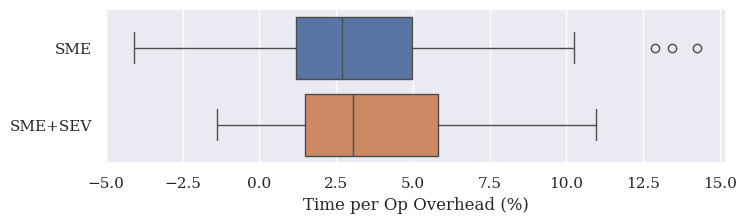

In [12]:
plt.figure(figsize=(8, 2))

sns.boxplot(
    data=overhead_df, 
    x="Time_per_op_pct", 
    y="Mode", 
    hue="Mode",
)

plt.xlabel("Time per Op Overhead (%)")
plt.ylabel("")
plt.savefig("images/Time_per_Op_Overhead_Distribution.pdf", bbox_inches='tight')
plt.show()

In [21]:
#90 percentile quartile
overhead_df["Time_per_op_pct"].quantile(0.9)

np.float64(6.993629032885397)

→ VM NUMA:
Mode        SME  SME+SEV
VM_NUMA                 
interleave  2.0      2.1
strict      4.3      5.0
------------------------------------------------------------
→ Cores:
Mode   SME  SME+SEV
Cores              
1      3.1      3.8
8      1.8      2.0
24     4.0      4.2
48     3.6      4.3
------------------------------------------------------------


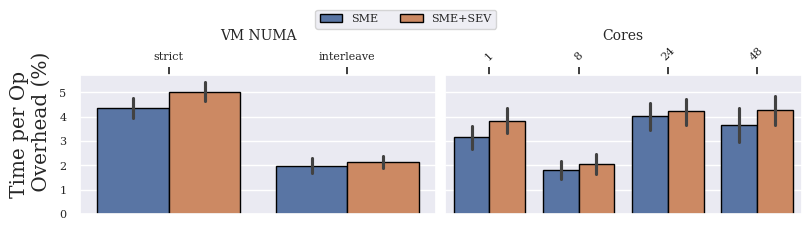

In [13]:
def plot_metric_by_dimensions(metric, metric_legend_name, top):
    all_dims = ["VM_NUMA","Cores"] 
    vm_numa_order= ["strict", "interleave"]

    fig, axes = plt.subplots( nrows=1, ncols=len(all_dims), figsize=(8, 2), constrained_layout=True, sharey=True) 

    fig.supylabel(f"{metric_legend_name} Overhead (%)")
    for ax, a in zip(axes, all_dims):
        sns.barplot( data=overhead_df, x=a, y=metric, hue='Mode', errorbar=("ci",95), edgecolor='black', order=vm_numa_order if a == "VM_NUMA" else None, ax=ax)

        if a=="Matrix":
            ax.set_title("Matrix Size",y=1.2, fontsize=9)
        else:
            ax.set_title(a.replace("_", " "),y=1.2, fontsize=10)
        ax.set_ylabel("")
        ax.set_xlabel("")
        rotation = 0 if a in ['VM_NUMA'] else 45
        ax.tick_params(axis='x', rotation=rotation, labelsize=8)
        if top:
            ax.xaxis.set_ticks_position('top')
            ax.xaxis.set_label_position('top')
        else:
            ax.xaxis.set_ticks_position('bottom')
            ax.xaxis.set_label_position('bottom')
        ax.tick_params(axis='y', labelsize=8)
        ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=8)
    plt.savefig("images/krylov_overhead_by_dim.pdf", bbox_inches="tight")

    for dim in all_dims:
        print(f"→ {dim.replace('_', ' ')}:")
        summary = (overhead_df.groupby([dim, 'Mode'])[metric]
                   .mean()
                   .round(2)
                   .reset_index())
        
        summary_pivot = summary.pivot(index=dim, columns='Mode', values=metric)
        
        print(summary_pivot.to_string(float_format="{:.1f}".format))
        print("-" * 60)

plot_metric_by_dimensions("Time_per_op_pct", "Time per Op\n", top=True)

/tmp/ipykernel_4062754/3642055370.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_4062754/3642055370.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha="right")



Symmetric displayed values (Time_per_op_pct):
Group       cg + SME  cg + SME+SEV  lanczos + SME  lanczos + SME+SEV
Matrix                                                              
dawson5         1.36          1.40           1.25               1.97
G3_circuit      4.55          5.62           4.21               4.66
nd12k           2.52          2.80           2.49               2.72
Hook_1498       2.86          3.21           3.31               4.13
Bump2911        2.72          2.61           3.36               3.53

Unsymmetric displayed values (Time_per_op_pct):
Group          bicgstab + SME  bicgstab + SME+SEV  arnoldi + SME  arnoldi + SME+SEV
Matrix                                                                             
e40r0100                 2.13                2.36           1.90               2.32
marine1                  3.03                3.44           3.97               4.39
Freescale1               5.10                5.47           3.95               4.23
R

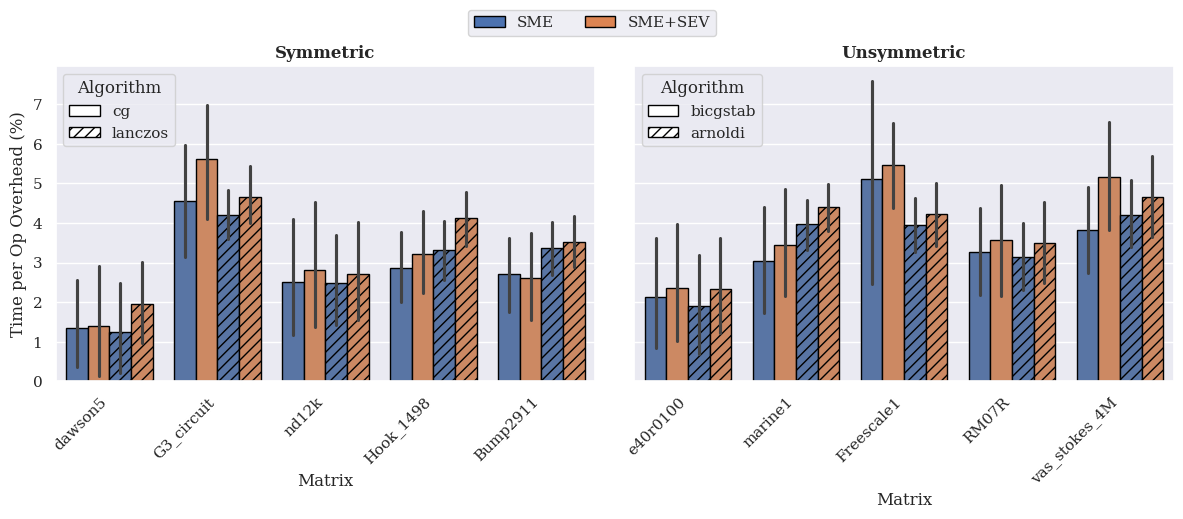

In [14]:
sym_algo_order = ["cg", "lanczos"]
unsym_algo_order = ["bicgstab", "arnoldi"]
algo_patterns = {"cg": "", "lanczos": "///", "bicgstab": "", "arnoldi": "///"}
matrix_order = [
'dawson5', 'G3_circuit', 'nd12k', 'Hook_1498',
'Bump2911', 'e40r0100', 'marine1', 'Freescale1',
'RM07R', 'vas_stokes_4M'
]

# Map colors to Mode (default seaborn colors)
default_colors = sns.color_palette(n_colors=2)
modes_palette = {"SME": default_colors[0], "SME+SEV": default_colors[1]}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for idx, (is_symmetric, title) in enumerate([(True, "Symmetric"), (False, "Unsymmetric")]):
    sub = overhead_df[overhead_df["Symmetric"] == is_symmetric].copy()

    sub["Group"] = sub["Algo"] + " + " + sub["Mode"]
    
    current_algos = sym_algo_order if is_symmetric else unsym_algo_order
    hue_order = []
    for algo in current_algos:
        for mode in ["SME", "SME+SEV"]:
            hue_order.append(f"{algo} + {mode}")

    sns.barplot(
        data=sub,
        x="Matrix",
        y="Time_per_op_pct",
        hue="Group",
        hue_order=hue_order,
        order=[m for m in matrix_order if m in sub["Matrix"].unique()],
        palette=[modes_palette[s.split(" + ")[1]] for s in hue_order],
        errorbar=("ci", 95),
        ax=axes[idx]
    )

	#Hatching by Algorithm
    for container, group_label in zip(axes[idx].containers, hue_order):
        algo_name = group_label.split(" + ")[0].lower()
        pattern = algo_patterns.get(algo_name, "")
        
        for bar in container:
            bar.set_hatch(pattern)
            bar.set_edgecolor("black")

    axes[idx].set_title(f"{title}", fontweight='bold')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha="right")
    axes[idx].get_legend().remove()

    if idx == 0:
        axes[idx].set_ylabel("Time per Op Overhead (%)")
    else:
        axes[idx].set_ylabel("")
        axes[idx].tick_params(axis="y", labelleft=False)

    algo_handles = [
        Patch(facecolor="white", edgecolor="black", hatch=algo_patterns.get(a.lower(), ""), label=a) 
        for a in current_algos
    ]
    axes[idx].legend(handles=algo_handles, title="Algorithm", loc="upper left")

    print(f"\n{title} displayed values (Time_per_op_pct):")
    displayed_values = (
        sub.groupby(["Matrix", "Group"])["Time_per_op_pct"]
        .mean()
        .unstack("Group")
        .reindex(index=[m for m in matrix_order if m in sub["Matrix"].unique()], columns=hue_order)
    )
    print(displayed_values.round(2).to_string())

# --- 4. Global Legend for Colors (Modes) ---
mode_handles = [Patch(facecolor=modes_palette[m], edgecolor="black", label=m) for m in ["SME", "SME+SEV"]]
fig.legend(handles=mode_handles, title=None, loc="upper center", 
           bbox_to_anchor=(0.5, 1.05), ncol=2)

plt.tight_layout()
plt.savefig("images/krylov_overhead_by_algo_matrix.pdf", bbox_inches="tight")
plt.show()

## Hardware counter

In [15]:
overhead_df.groupby("Mode")[["Perf_Instructions_pct","Perf_Cycles_pct"]].aggregate(['mean', 'std']).round(1)

Perf_Instructions_pct      Perf_Cycles_pct     
                         mean  std            mean  std
Mode                                                   
SME                       0.1  0.4             2.2  2.1
SME+SEV                   0.1  0.4             2.3  2.3

In [16]:
for metric, label in [
    ("Perf_CacheMisses_pct", "Cache Misses"),
    ("Perf_dTLBMisses_pct", "dTLB Misses"),
]:
    print(f"{label}:")
    print(overhead_df.groupby("Mode")[metric].median().round(2).to_string())
    print(f"IQR Relative {label} (%):")
    iqr = overhead_df.groupby("Mode")[metric].agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
    print(iqr.round(2).to_string())
    print()

Cache Misses:
Mode
SME        0.17
SME+SEV    0.05
IQR Relative Cache Misses (%):
Mode
SME        7.49
SME+SEV    7.59

dTLB Misses:
Mode
SME        1.46
SME+SEV    6.18
IQR Relative dTLB Misses (%):
Mode
SME        12.41
SME+SEV    20.90



         Perf_dTLBMisses_pct
Mode                        
SME                     1.46
SME+SEV                 6.18


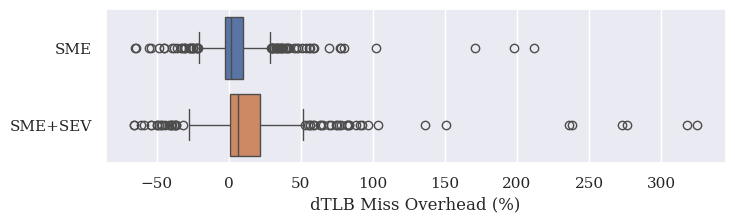

In [17]:
plt.figure(figsize=(8, 2))

sns.boxplot(
    data=overhead_df, 
    x="Perf_dTLBMisses_pct", 
    y="Mode", 
    hue="Mode",
)
plt.xlabel("dTLB Miss Overhead (%)")
plt.ylabel("")
plt.savefig("images/CacheMiss_Overhead_Distribution.pdf", bbox_inches='tight')

print(overhead_df.groupby("Mode")[["Perf_dTLBMisses_pct"]].median().round(2).to_string())

Pearson : 0.08688917095687244
Spearman: 0.09890092789784678


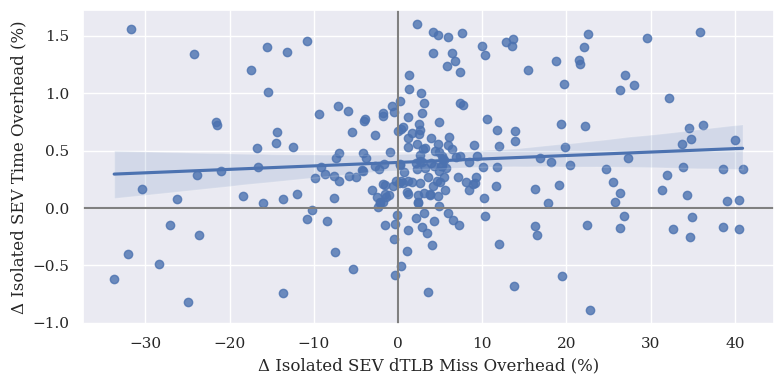

In [20]:
pivot = overhead_df.pivot_table(
    index=["Matrix", "Cores", "VM_NUMA", "Process_NUMA", "Algo"],
    columns="Mode",
    values=["Time_per_op_pct", "Perf_dTLBMisses_pct"]
)

pivot.columns = ["_".join(col) for col in pivot.columns]

pivot["Time_diff"] = ( pivot["Time_per_op_pct_SME+SEV"] - pivot["Time_per_op_pct_SME"])
pivot["dTLB_diff"] = ( pivot["Perf_dTLBMisses_pct_SME+SEV"] - pivot["Perf_dTLBMisses_pct_SME"])

corr_df = pivot[["Time_diff", "dTLB_diff"]].dropna().copy()
corr_iqr = iqr_filter(corr_df, ["Time_diff", "dTLB_diff"])

print("Pearson :", corr_iqr["Time_diff"].corr(corr_iqr["dTLB_diff"], method="pearson"))
print("Spearman:", corr_iqr["Time_diff"].corr(corr_iqr["dTLB_diff"], method="spearman"))

plt.figure(figsize=(8, 4))
sns.regplot( data=corr_iqr, x="dTLB_diff", y="Time_diff")
plt.axhline(0, color="gray")
plt.axvline(0, color="gray")

plt.xlabel("Δ Isolated SEV dTLB Miss Overhead (%)")
plt.ylabel("Δ Isolated SEV Time Overhead (%)")
plt.tight_layout()
plt.savefig("images/krylov_time_dtlb_correlation.pdf", bbox_inches="tight")
plt.show()

In [19]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
targets = [ "SpMV_GFLOPS_pct" ]

def full_anova(df, target):
    d = df.dropna(subset=[ target, "Algo", "Cores", "Matrix", "Process_NUMA", "VM_NUMA"]).copy()

	# C for categorical, handled internally by statsmodels
    formula = f"{target} ~ C(Algo) + C(Matrix) + Cores + C(Process_NUMA) + C(VM_NUMA)"

    model = ols(formula, data=d).fit()

    #https://md.psych.bio.uni-goettingen.de/mv/unit/lm_cat/lm_cat_unbal_ss_explained.html
    table = sm.stats.anova_lm(model, typ=3)

    table["eta_sq"] = table["sum_sq"] / table["sum_sq"].sum()

    return table.sort_values("eta_sq", ascending=False)
dtlb_target = "Perf_dTLBMisses_pct"

for mode in ["SME", "SME+SEV"]:
	anova = full_anova(overhead_df[overhead_df["Mode"] == mode].copy(), dtlb_target)
	factors = anova.drop(index="Residual", errors="ignore").sort_values("eta_sq", ascending=False)

	print(f"\n=== {mode}: drivers of {dtlb_target} ===")
	print(factors[["sum_sq", "df", "F", "PR(>F)", "eta_sq"]].to_string(float_format="{:.4f}".format))

	top_factor = factors.index[0]
	print(f"Top driver: {top_factor} (eta_sq={factors.iloc[0]['eta_sq']:.3f})")


=== SME: drivers of Perf_dTLBMisses_pct ===
                    sum_sq     df      F  PR(>F)  eta_sq
C(Matrix)       14591.7893 9.0000 2.2500  0.0190  0.0601
C(Algo)          7763.7385 3.0000 3.5914  0.0141  0.0320
C(Process_NUMA)   319.7564 1.0000 0.4437  0.5058  0.0013
Intercept          64.9961 1.0000 0.0902  0.7641  0.0003
C(VM_NUMA)         60.3627 1.0000 0.0838  0.7724  0.0002
Cores              43.4437 1.0000 0.0603  0.8062  0.0002
Top driver: C(Matrix) (eta_sq=0.060)

=== SME+SEV: drivers of Perf_dTLBMisses_pct ===
                    sum_sq     df       F  PR(>F)  eta_sq
C(Matrix)       82373.3286 9.0000  5.0352  0.0000  0.1179
C(VM_NUMA)      27784.1971 1.0000 15.2852  0.0001  0.0398
C(Algo)         27633.1343 3.0000  5.0674  0.0019  0.0396
Cores            5036.5201 1.0000  2.7708  0.0970  0.0072
Intercept        1312.1443 1.0000  0.7219  0.3962  0.0019
C(Process_NUMA)    13.3228 1.0000  0.0073  0.9318  0.0000
Top driver: C(Matrix) (eta_sq=0.118)
